# Discretization: Unsupervised and supervised

- Discretization is data-dependent — not always beneficial, but worth testing.

## A) Unsupervised
- These methods do not use the target variable.

In [4]:
import pandas as pd
import numpy as np

data = pd.DataFrame({'age': [22, 25, 47, 52, 46, 56, 44, 48, 51, 60]})

# 1) Equal Width Binning (Uniform Binning)
# Bin width = (max(X) - min(X)) / k

data['age_bin'] = pd.cut(data['age'], bins=4)
# print(data)


# 2. Equal Frequency Binning (Quantile Binning)
data['age_bin_quantile'] = pd.qcut(data['age'], q=4)
# print(data)


# 3. Clustering-Based Discretization (e.g., K-Means)
from sklearn.cluster import KMeans

X = data[['age']]
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
data['age_bin_kmeans'] = kmeans.labels_
print(data)


   age         age_bin age_bin_quantile  age_bin_kmeans
0   22  (21.962, 31.5]   (21.999, 44.5]               1
1   25  (21.962, 31.5]   (21.999, 44.5]               1
2   47    (41.0, 50.5]     (44.5, 47.5]               2
3   52    (50.5, 60.0]    (51.75, 60.0]               0
4   46    (41.0, 50.5]     (44.5, 47.5]               2
5   56    (50.5, 60.0]    (51.75, 60.0]               0
6   44    (41.0, 50.5]   (21.999, 44.5]               2
7   48    (41.0, 50.5]    (47.5, 51.75]               2
8   51    (50.5, 60.0]    (47.5, 51.75]               2
9   60    (50.5, 60.0]    (51.75, 60.0]               0


## B) Supervised Discretization
- These methods use the target variable to determine binning, aiming to improve class separation.

In [5]:
# 1) Decision Tree-Based Discretization
# Use a decision tree (e.g., DecisionTreeClassifier) to find 
# split points in the continuous variable that best separate the classes.

from sklearn.tree import DecisionTreeClassifier

data = pd.DataFrame({'age': [22, 25, 47, 52, 46, 56, 44, 48, 51, 60]})

# Assume we have target variable 'label'
X = data[['age']]
y = [0, 0, 1, 1, 1, 1, 1, 1, 1, 1]  # e.g., 0 = young group, 1 = senior group

tree = DecisionTreeClassifier(max_leaf_nodes=3)
tree.fit(X, y)
thresholds = tree.tree_.threshold[tree.tree_.threshold > 0]

print("Split points:", thresholds)

Split points: [34.5]


In [ ]:
# OPTIONAL

# 2. ChiMerge / Chi2 Discretization
# Merges adjacent intervals based on statistical significance (chi-squared test).
# Often used in feature selection + discretization.

# 3. Entropy-Based Binning (MDLP)
# Minimum Description Length Principle (MDLP) chooses cut points that minimize entropy.
# Tries to compress data + class distribution optimally.

# Lets try this on titanic dataset (Here it was not beneficial, but worth testing.)
**Here we will use binning on one feature only: age**.

Compare the performance of a simple classifier (e.g., Logistic Regression or Decision Tree) when Age is:

1) Used as-is (continuous),

2) Discretized using:
- Equal Width Binning,
- Equal Frequency Binning,
- K-Means Binning,
- Decision Tree-Based Binning.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load Titanic dataset from seaborn
import seaborn as sns
df = sns.load_dataset("titanic")

# Keep relevant features
df = df[['age', 'sex', 'fare', 'pclass', 'survived']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})  # Encode categorical

X = df.drop('survived', axis=1)
y = df['survived']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score

def train_and_evaluate(X_train, X_test, y_train, y_test, description):
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy with {description}: {acc:.4f}")


In [9]:
train_and_evaluate(X_train, X_test, y_train, y_test, "no discretization")


Accuracy with no discretization: 0.7907


In [10]:
def equal_width_binning(X, n_bins=4):
    binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    X_copy = X.copy()
    X_copy['age'] = binner.fit_transform(X[['age']])
    return X_copy

X_train_eqw = equal_width_binning(X_train)
X_test_eqw = equal_width_binning(X_test)
train_and_evaluate(X_train_eqw, X_test_eqw, y_train, y_test, "equal width binning")


Accuracy with equal width binning: 0.7721


In [11]:
def equal_freq_binning(X, n_bins=4):
    binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    X_copy = X.copy()
    X_copy['age'] = binner.fit_transform(X[['age']])
    return X_copy

X_train_eqf = equal_freq_binning(X_train)
X_test_eqf = equal_freq_binning(X_test)
train_and_evaluate(X_train_eqf, X_test_eqf, y_train, y_test, "equal frequency binning")


Accuracy with equal frequency binning: 0.7814


In [12]:
def kmeans_binning(X, n_bins=4):
    binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans')
    X_copy = X.copy()
    X_copy['age'] = binner.fit_transform(X[['age']])
    return X_copy

X_train_km = kmeans_binning(X_train)
X_test_km = kmeans_binning(X_test)
train_and_evaluate(X_train_km, X_test_km, y_train, y_test, "k-means binning")


Accuracy with k-means binning: 0.7674


In [13]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

def tree_binning(X_train, X_test, y_train, max_leaf_nodes=4):
    tree = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes)
    tree.fit(X_train[['age']], y_train)
    thresholds = tree.tree_.threshold[tree.tree_.threshold > 0]
    bins = np.sort(np.unique(thresholds))
    bins = np.concatenate(([-np.inf], bins, [np.inf]))

    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    X_train_copy['age'] = pd.cut(X_train['age'], bins=bins, labels=False)
    X_test_copy['age'] = pd.cut(X_test['age'], bins=bins, labels=False)
    return X_train_copy, X_test_copy

X_train_tree, X_test_tree = tree_binning(X_train, X_test, y_train)
train_and_evaluate(X_train_tree, X_test_tree, y_train, y_test, "decision tree binning")


Accuracy with decision tree binning: 0.7907


### observation: Here binning did not do much. Although among different bin techniques we see that using Decsion Tree gave higher accuracy

# Apply binning to multiple columns (Here it was not beneficial, but worth testing.)
**Here we will use binning on more than one feature**.


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load and clean Titanic data
df = sns.load_dataset("titanic")
df = df[['age', 'fare', 'pclass', 'sex', 'survived']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

X = df.drop('survived', axis=1)
y = df['survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)


In [15]:
def train_and_evaluate(X_train, X_test, y_train, y_test, description):
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{description:<40}: Accuracy = {acc:.4f}")


In [16]:
def apply_binning(X_train, X_test, columns, strategy="uniform", n_bins=4):
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    
    binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
    binner.fit(X_train_copy[columns])

    X_train_copy[columns] = binner.transform(X_train_copy[columns])
    X_test_copy[columns] = binner.transform(X_test_copy[columns])
    
    return X_train_copy, X_test_copy


In [17]:
def tree_binning_supervised(X_train, X_test, y_train, columns, max_leaf_nodes=4):
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    
    for col in columns:
        tree = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes)
        tree.fit(X_train_copy[[col]], y_train)
        thresholds = tree.tree_.threshold[tree.tree_.threshold > 0]
        bins = np.sort(np.unique(thresholds))
        bins = np.concatenate(([-np.inf], bins, [np.inf]))
        
        X_train_copy[col] = pd.cut(X_train_copy[col], bins=bins, labels=False)
        X_test_copy[col] = pd.cut(X_test_copy[col], bins=bins, labels=False)

    return X_train_copy, X_test_copy


In [18]:
train_and_evaluate(X_train, X_test, y_train, y_test, "Original (No Discretization)")


Original (No Discretization)            : Accuracy = 0.7907


In [19]:
X_eqw_train, X_eqw_test = apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], strategy='uniform')
train_and_evaluate(X_eqw_train, X_eqw_test, y_train, y_test, "Equal Width Binning")


Equal Width Binning                     : Accuracy = 0.7674


In [20]:
X_eqf_train, X_eqf_test = apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], strategy='quantile')
train_and_evaluate(X_eqf_train, X_eqf_test, y_train, y_test, "Equal Frequency Binning")


Equal Frequency Binning                 : Accuracy = 0.7767


c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [21]:
X_km_train, X_km_test = apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], strategy='kmeans')
train_and_evaluate(X_km_train, X_km_test, y_train, y_test, "K-Means Binning")


K-Means Binning                         : Accuracy = 0.7767


c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [22]:
X_tree_train, X_tree_test = tree_binning_supervised(X_train, X_test, y_train, ['age', 'fare', 'pclass'])
train_and_evaluate(X_tree_train, X_tree_test, y_train, y_test, "Decision Tree Binning")


Decision Tree Binning                   : Accuracy = 0.7814


In [ ]:
# observation: Binning did not increase the accuracy

# ( OPTIONAL ) Visualization
Let's enhance the project with visualizations to understand how each discretization method transforms the distribution of features like age, fare, and pclass.

We'll use matplotlib and seaborn to plot histograms for each method.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms(original, binned, column, method_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(original[column], kde=False, bins=20, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Original '{column}' Distribution")
    
    sns.histplot(binned[column], kde=False, bins=len(binned[column].unique()), ax=axes[1], color='salmon')
    axes[1].set_title(f"{method_name} Binned '{column}'")
    
    for ax in axes:
        ax.set_xlabel(column)
        ax.set_ylabel("Count")
    
    plt.tight_layout()
    plt.show()


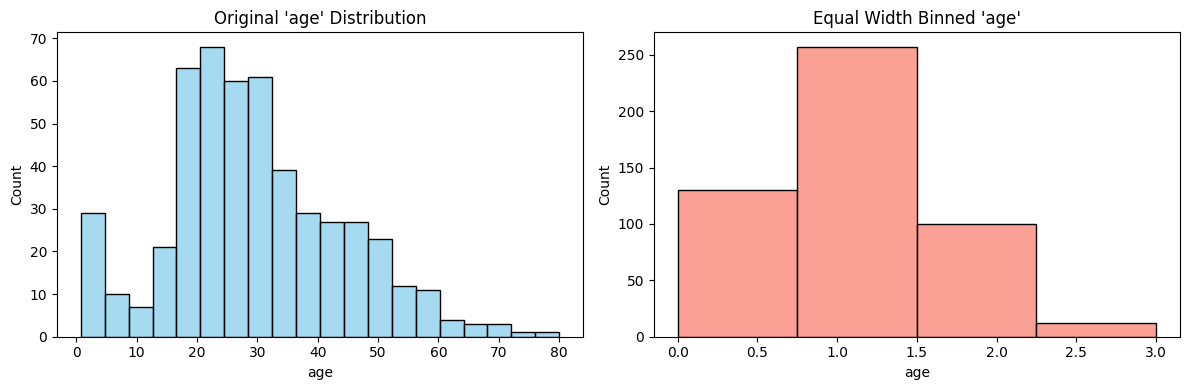

In [24]:
X_eqw_train, _ = apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], strategy='uniform')
plot_histograms(X_train, X_eqw_train, 'age', "Equal Width")


c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


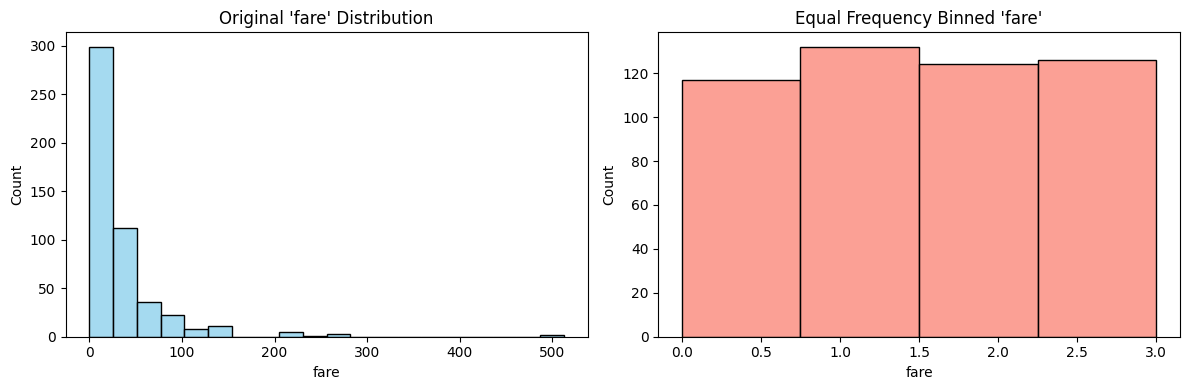

In [25]:
X_eqf_train, _ = apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], strategy='quantile')
plot_histograms(X_train, X_eqf_train, 'fare', "Equal Frequency")


c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


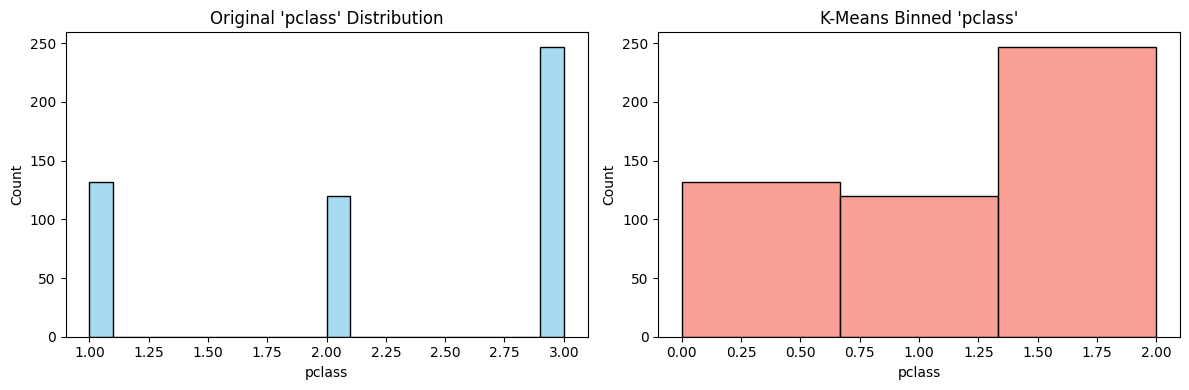

In [26]:
X_km_train, _ = apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], strategy='kmeans')
plot_histograms(X_train, X_km_train, 'pclass', "K-Means")


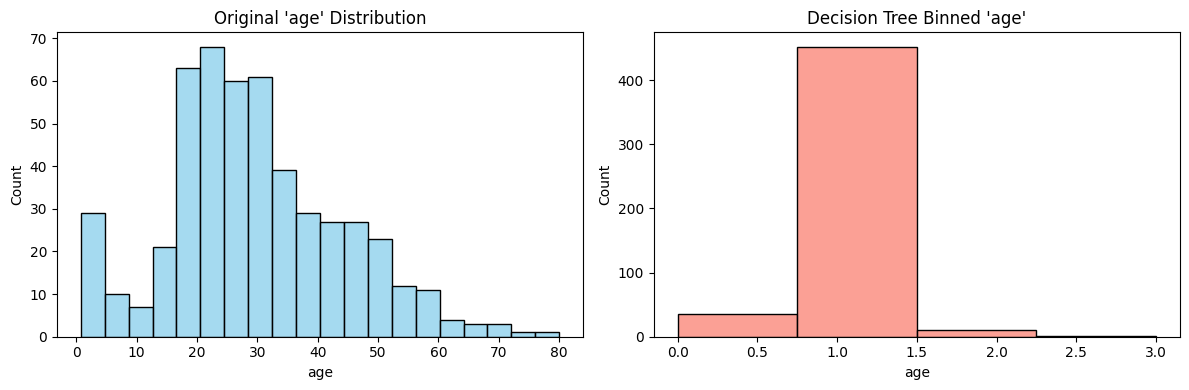

In [27]:
X_tree_train, _ = tree_binning_supervised(X_train, X_test, y_train, ['age', 'fare', 'pclass'])
plot_histograms(X_train, X_tree_train, 'age', "Decision Tree")


c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


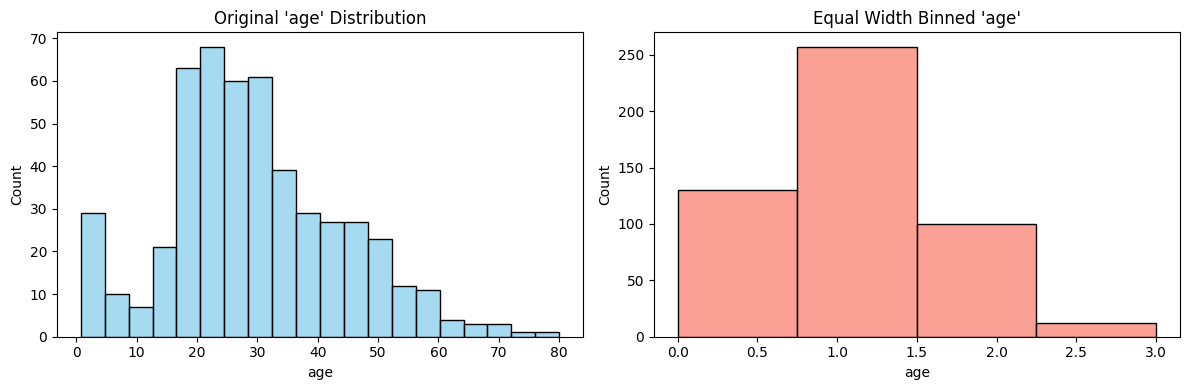

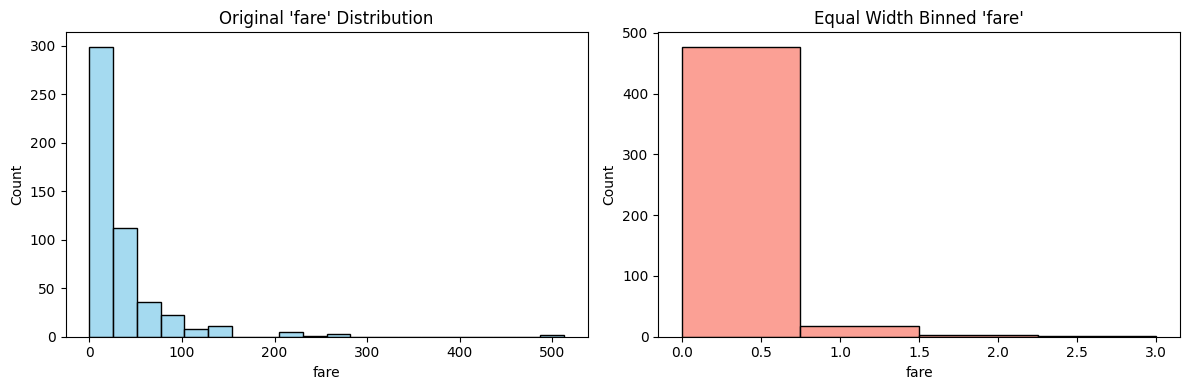

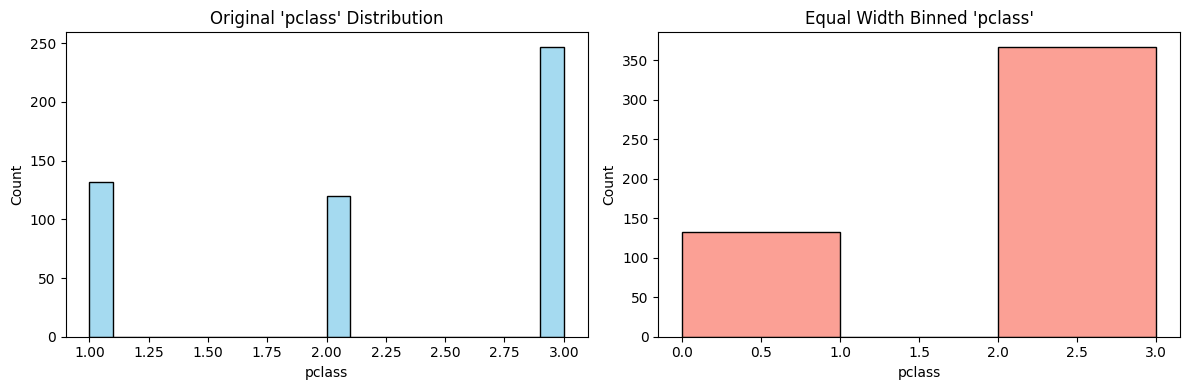

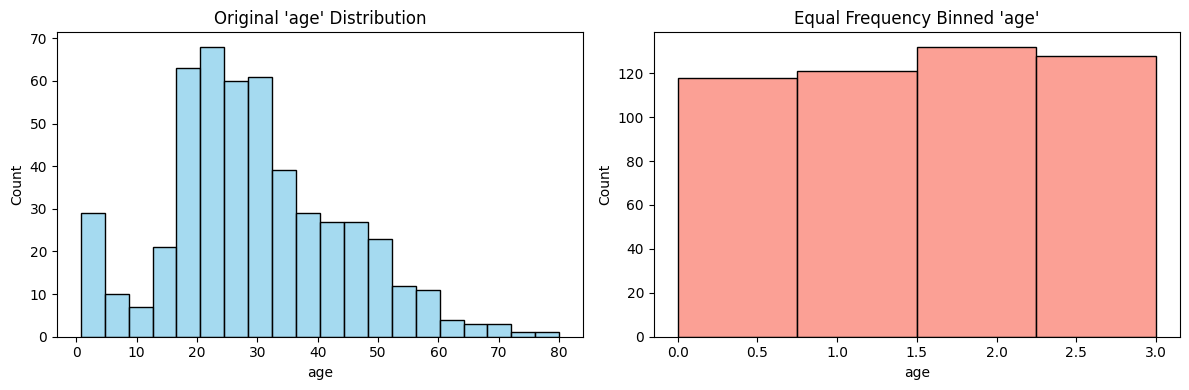

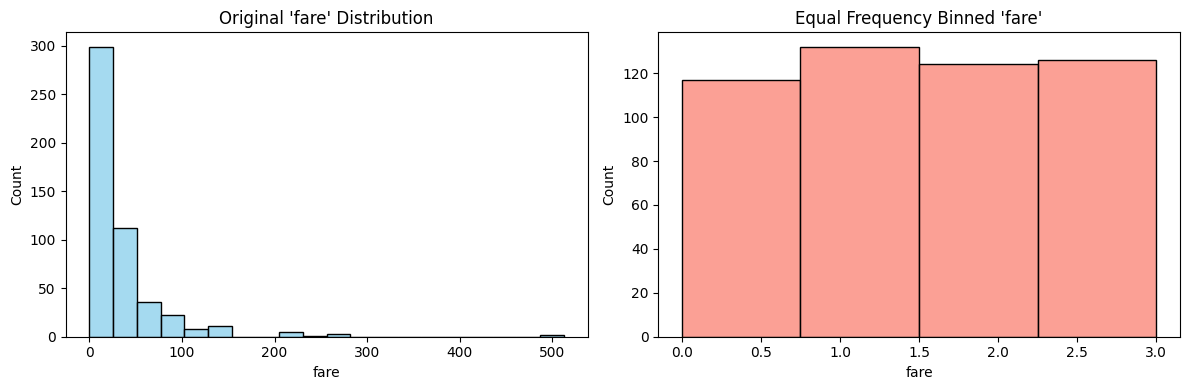

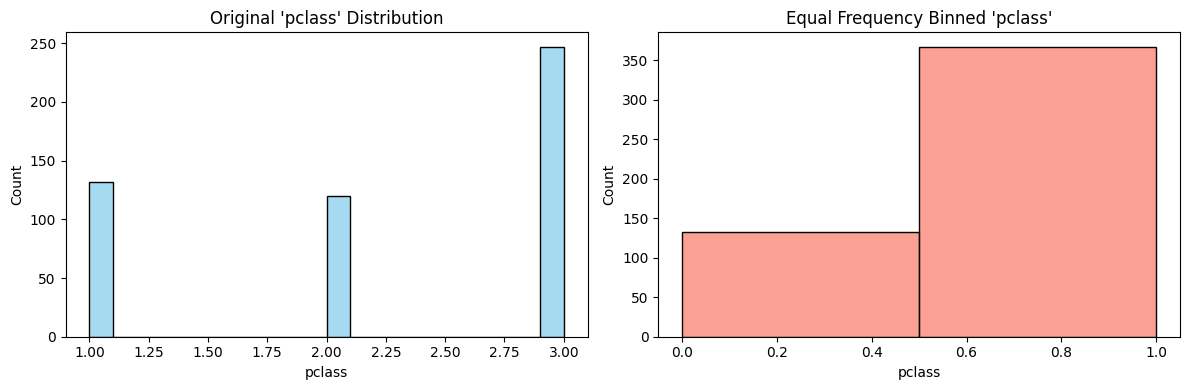

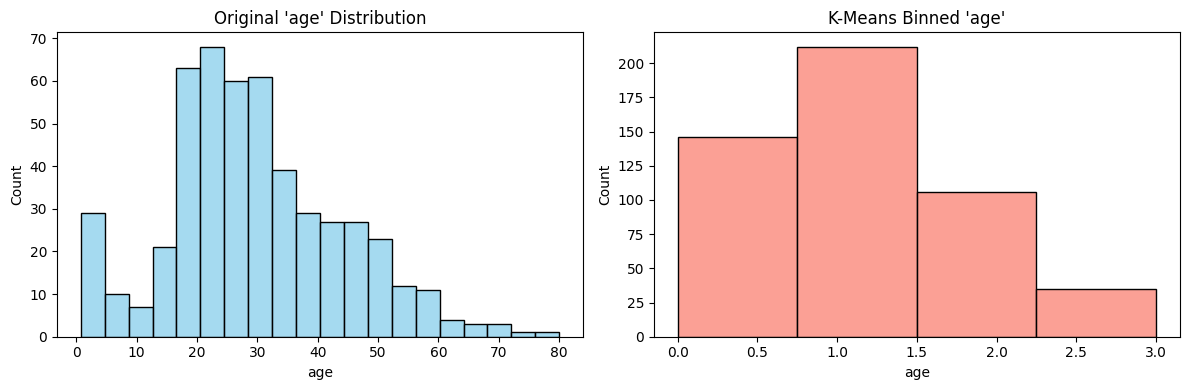

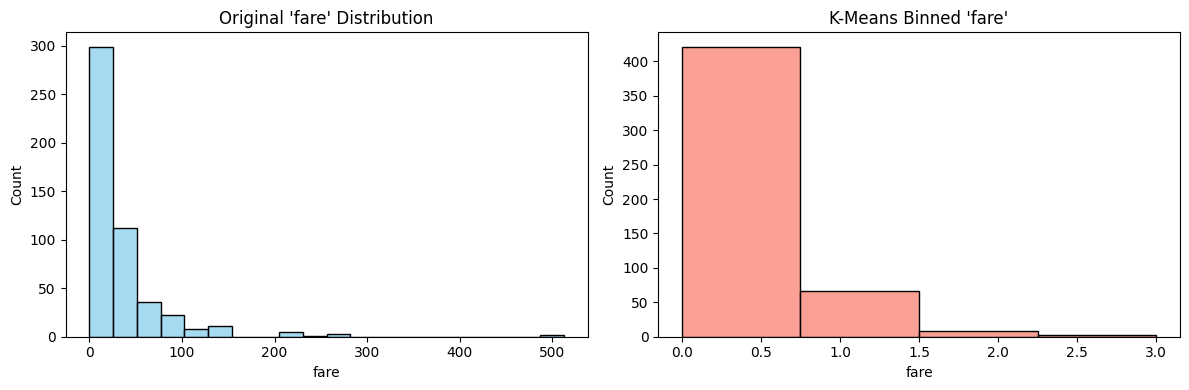

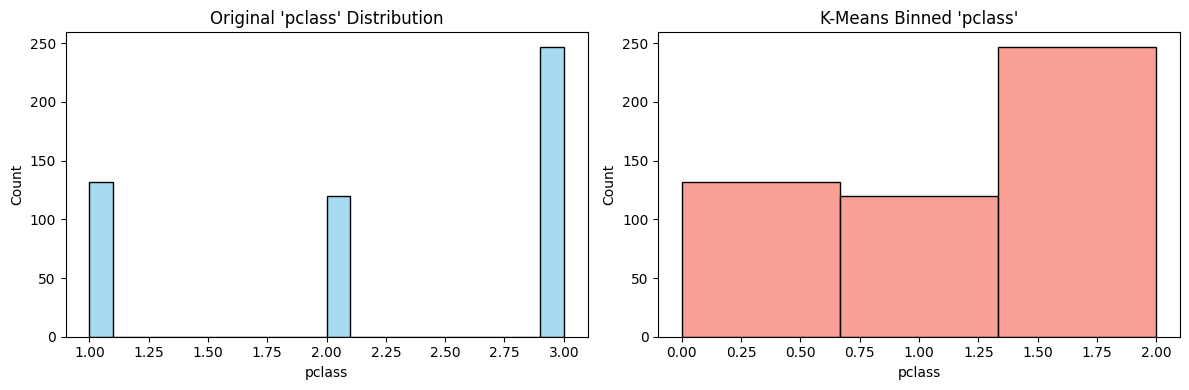

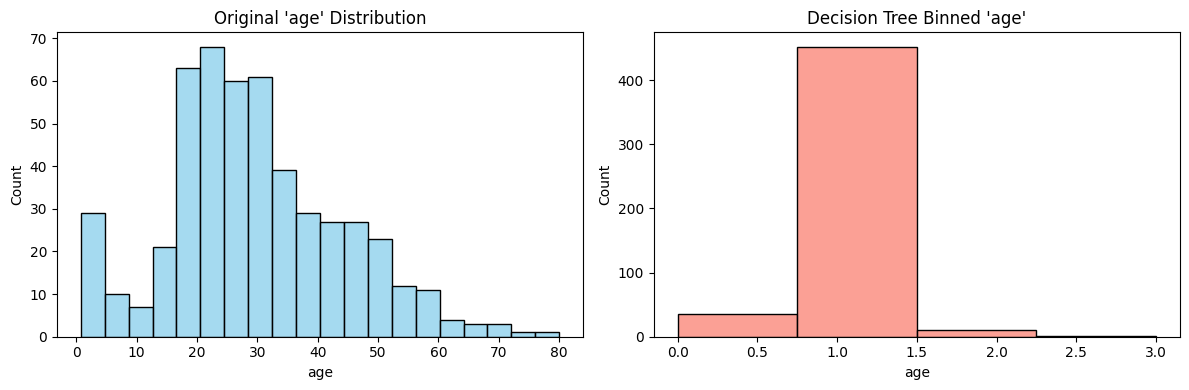

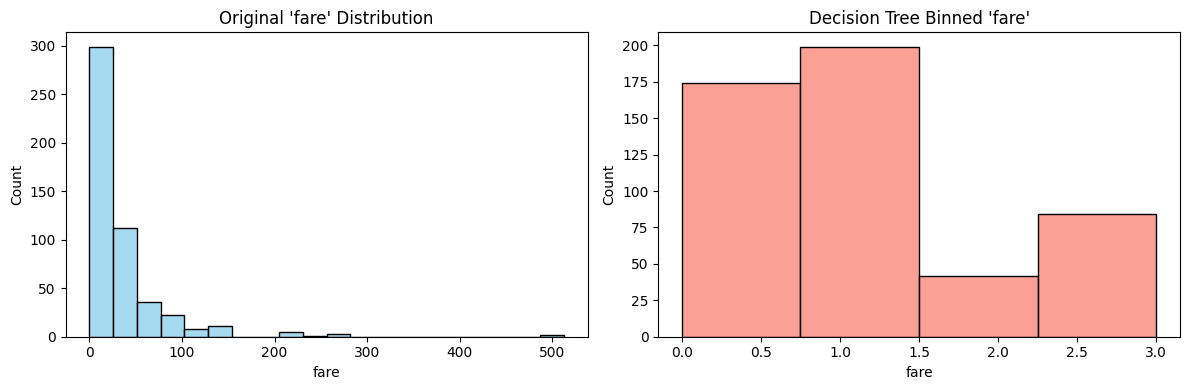

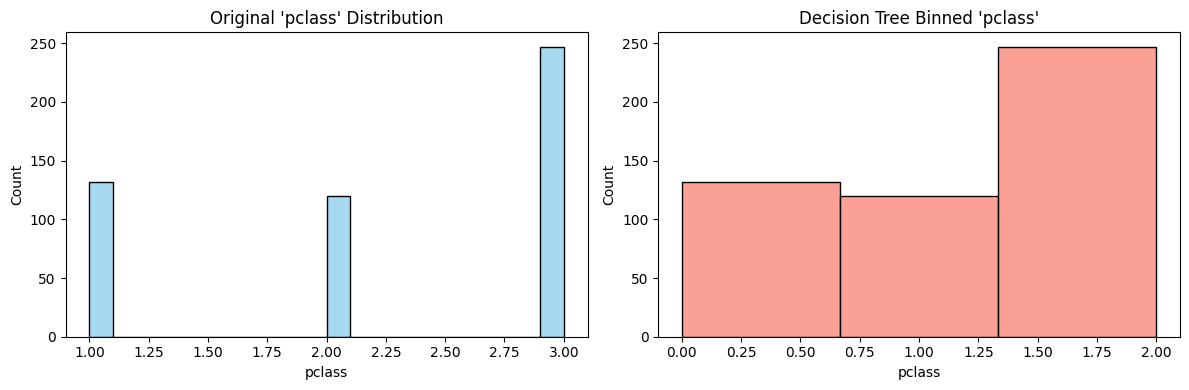

In [28]:
methods = {
    'Equal Width': apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], 'uniform')[0],
    'Equal Frequency': apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], 'quantile')[0],
    'K-Means': apply_binning(X_train, X_test, ['age', 'fare', 'pclass'], 'kmeans')[0],
    'Decision Tree': tree_binning_supervised(X_train, X_test, y_train, ['age', 'fare', 'pclass'])[0]
}

for method_name, binned_data in methods.items():
    for col in ['age', 'fare', 'pclass']:
        plot_histograms(X_train, binned_data, col, method_name)
